In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'bright', 'vpedre'])
from classy import Class
import pandas as pd

import os
os.chdir('../')
import python.vp_utils as utils
from pathlib import Path
parameters_sim = utils.parameters_sim

In [2]:
models = ['lcdm', 'frhs', 'ndgp']
base_path = Path('output_cosma')

C_ells_XY = {}
ell_grid = {}
SNR = {}

# Loop over models
for model in models:
    C_ells_XY[model] = np.load(base_path / model / 'C_ells_XY.npy', allow_pickle=True).item()
    ell_grid[model]  = np.load(base_path / model / 'ell_grid.npy')
    SNR[model] = np.load(base_path / model / 'SNR.npy', allow_pickle=True)

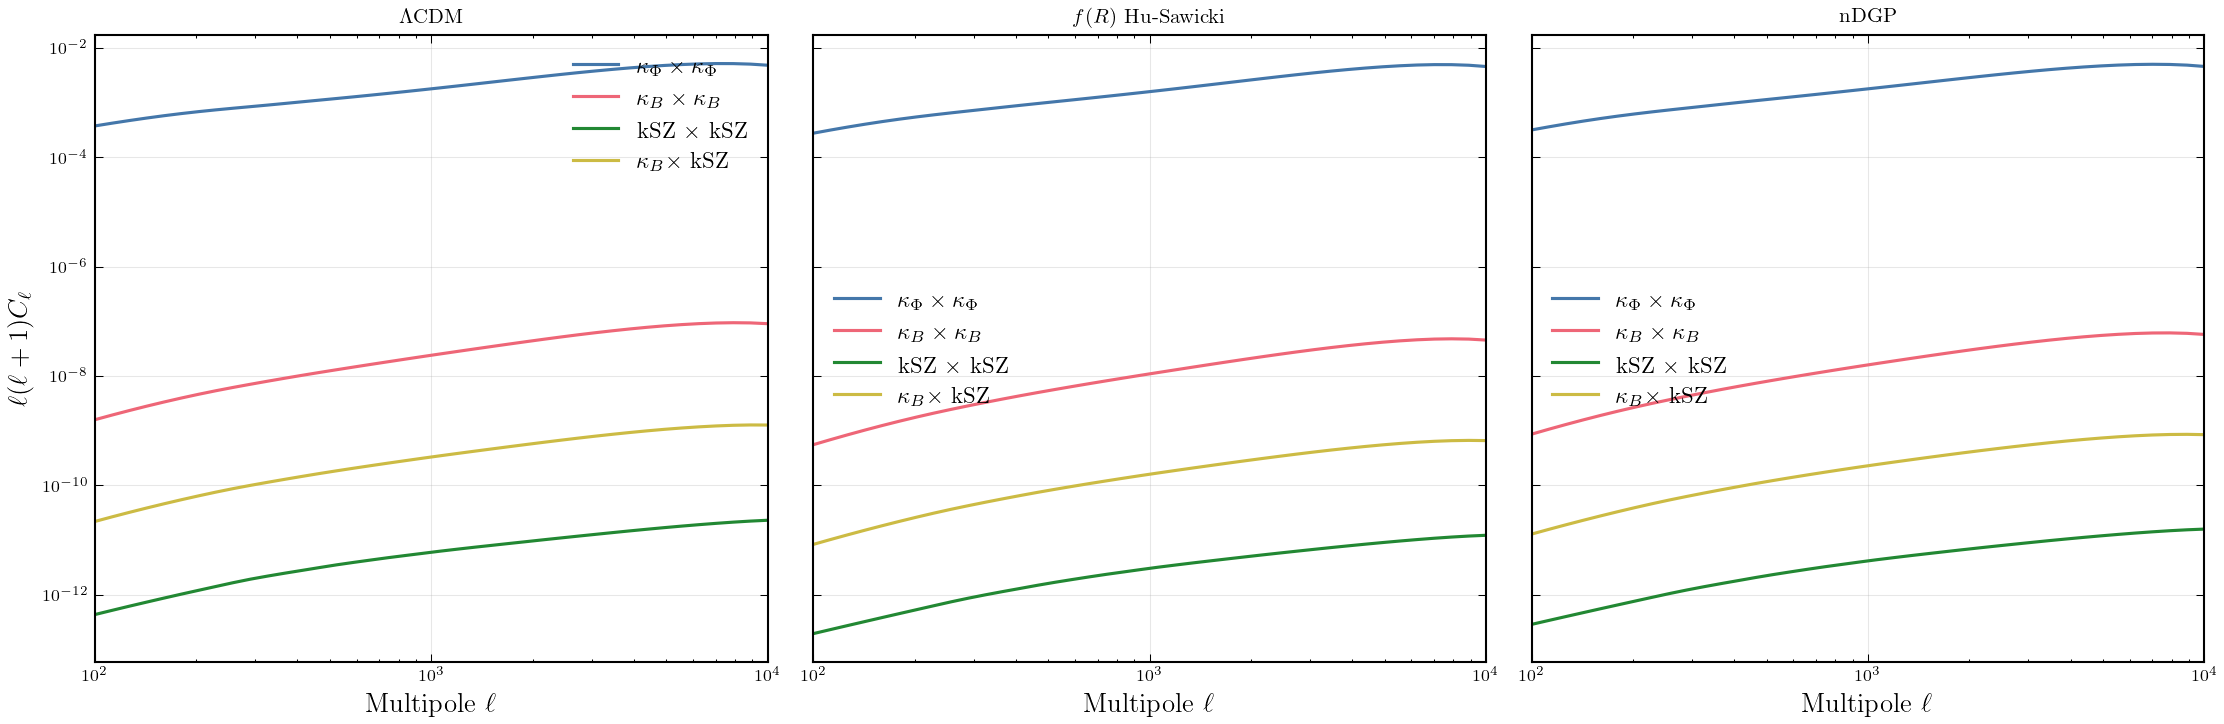

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15,5), sharey=True)
ax = ax.flatten()

for idx, m in enumerate(models):
    ax[idx].loglog(ell_grid[m], ell_grid[m]*(ell_grid[m]+1)*C_ells_XY[m]['Phi'],       label=r"$\kappa_\Phi \times \kappa_\Phi$")
    ax[idx].loglog(ell_grid[m], ell_grid[m]*(ell_grid[m]+1)*C_ells_XY[m]['B'],         label=r"$\kappa_B \times \kappa_B$")
    ax[idx].loglog(ell_grid[m], ell_grid[m]*(ell_grid[m]+1)*C_ells_XY[m]['kSZ'],       label=r"kSZ $\times$ kSZ")
    ax[idx].loglog(ell_grid[m], ell_grid[m]*(ell_grid[m]+1)*C_ells_XY[m]['B_X_kSZ'],   label=r"$\kappa_B \times$ kSZ")
    
    if idx==0:
        ax[idx].set_ylabel(r"$\ell(\ell+1)C_\ell$", fontsize=13)
        
    ax[idx].set_xlabel(r"Multipole $\ell$", fontsize=13)
    
    ax[idx].legend(fontsize=11, loc="best", frameon=False)
    ax[idx].set_xlim(ell_grid[m].min(), ell_grid[m].max())
    
    if m=='lcdm': title='$\Lambda$CDM'
    if m=='frhs': title='$f(R)$ Hu-Sawicki'
    if m=='ndgp': title='nDGP'
    
    ax[idx].set_title(title)

plt.tight_layout()
plt.savefig('imgs/C_ells.pdf')
plt.show()

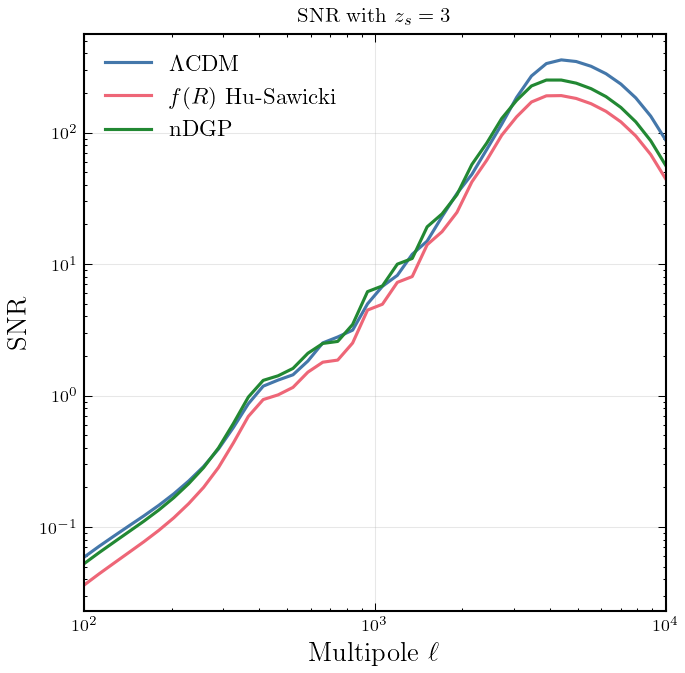

In [4]:
fig, ax = plt.subplots(figsize=(5,5))

for m in models:
    if m=='lcdm': title='$\Lambda$CDM'
    if m=='frhs': title='$f(R)$ Hu-Sawicki'
    if m=='ndgp': title='nDGP'
    
    ax.loglog(ell_grid[m], SNR[m], label=title)

ax.set_xlabel(r"Multipole $\ell$", fontsize=13)
ax.set_ylabel(r"SNR", fontsize=13)

ax.legend(fontsize=11, loc="best", frameon=False)
ax.set_xlim(ell_grid[m].min(), ell_grid[m].max())

ax.set_title("SNR with $z_s=3$")

plt.savefig('imgs/SNR.pdf')
plt.show()

## Redshift evolution

In [5]:
from collections import defaultdict
zz = np.arange(0.5, 3.1, 0.1) 
models = ['lcdm', 'frhs', 'ndgp']
base_path = Path('output_cosma')

C_ells_XY_z = defaultdict(dict)
ell_grid_z = defaultdict(dict)
SNR_z = defaultdict(dict)

# Loop over models
for model in models:
    for z in zz:
        z = np.round(z,1)
        C_ells_XY_z[model][z] = np.load(base_path / model / f'C_ells/C_ells_XY_z={z}.npy', allow_pickle=True).item()
        ell_grid_z[model][z]  = np.load(base_path / model / f'C_ells/ell_grid_z={z}.npy')
        SNR_z[model][z] = np.load(base_path / model / f'SNRs/SNR_z={z}.npy', allow_pickle=True)

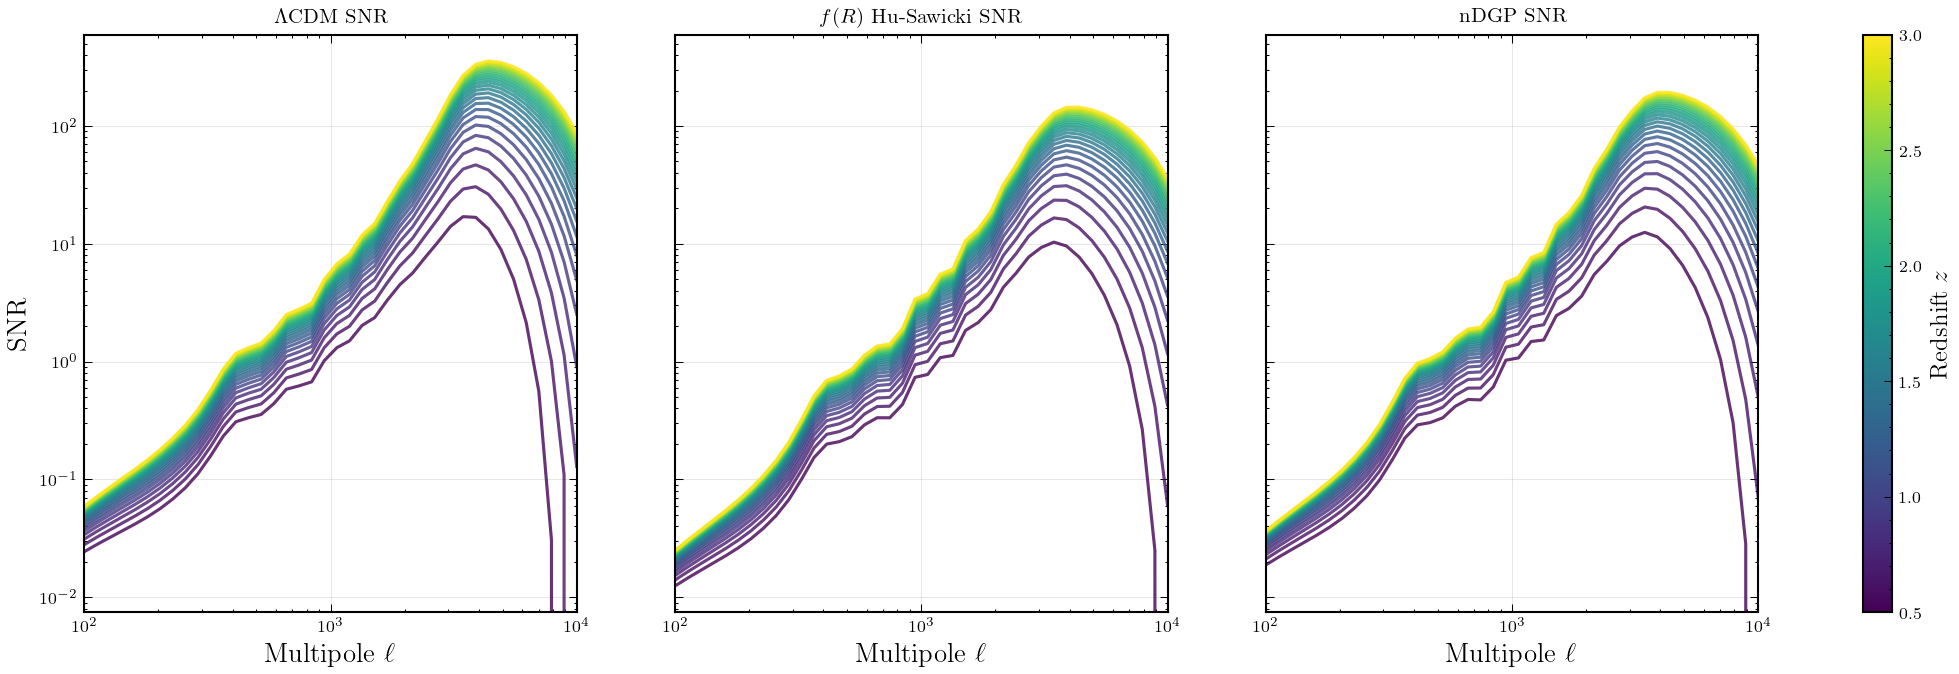

In [6]:
import matplotlib.cm as cm
import matplotlib.colors as colors

fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
ax.flatten()

titles = {'lcdm': '$\Lambda$CDM', 'frhs': '$f(R)$ Hu-Sawicki', 'ndgp': 'nDGP'}


cmap = cm.viridis  # 'magma' or 'plasma' are also great for cosmology
norm = colors.Normalize(vmin=min(zz), vmax=max(zz))

for idx, m in enumerate(models):
    for z in zz:
        z_key = np.round(z, 1)
        color = cmap(norm(z_key))
        ax[idx].loglog(ell_grid_z[m][z_key], SNR_z[m][z_key], color=color, alpha=0.8)

    ax[idx].set_xlim(ell_grid_z[m][3.0].min(), ell_grid_z[m][3.0].max())
    ax[idx].set_title(titles.get(m, m) + " SNR")
    ax[idx].set_xlabel(r"Multipole $\ell$", fontsize=13)

    if idx == 0:
        ax[idx].set_ylabel(r"SNR", fontsize=13)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required for matplotlib
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"Redshift $z$", fontsize=12)

plt.savefig(f'imgs/SNR_colorbar_{m}.pdf', bbox_inches='tight')
plt.show()

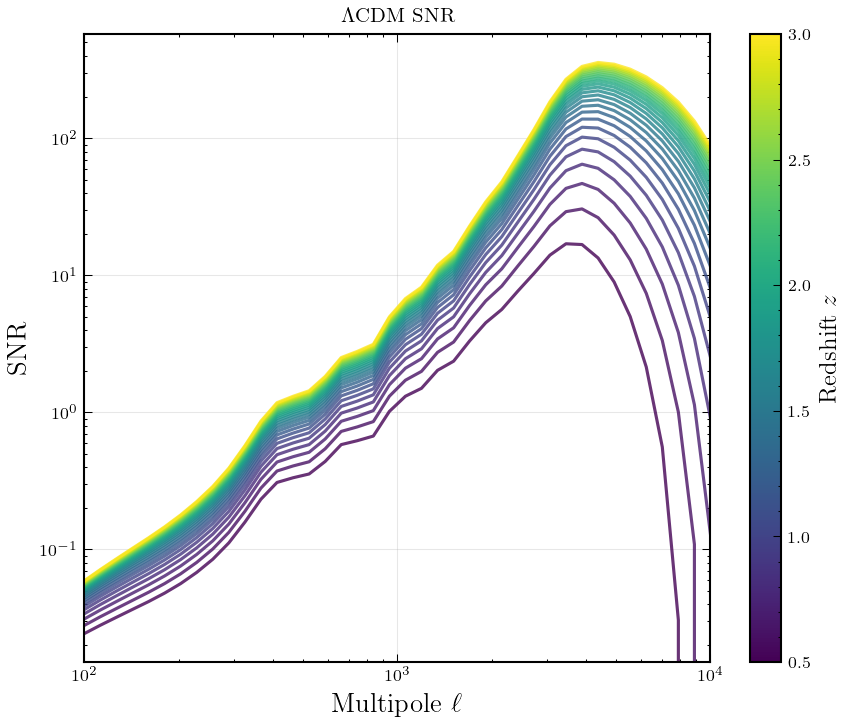

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))

m = 'lcdm'

if m=='lcdm': title='$\Lambda$CDM'
if m=='frhs': title='$f(R)$ Hu-Sawicki'
if m=='ndgp': title='nDGP'

for z in zz:
    z = np.round(z, 1)
    ax.loglog(ell_grid_z[m][z], SNR_z[m][z], label=z)

ax.set_xlabel(r"Multipole $\ell$", fontsize=13)
ax.set_ylabel(r"SNR", fontsize=13)

ax.legend(fontsize=11, loc="best", frameon=False)
ax.set_xlim(ell_grid_z[m][3].min(), ell_grid_z[m][3].max())

ax.set_title(title + " SNR")

plt.savefig('imgs/SNR.pdf')
plt.show()

# SNR

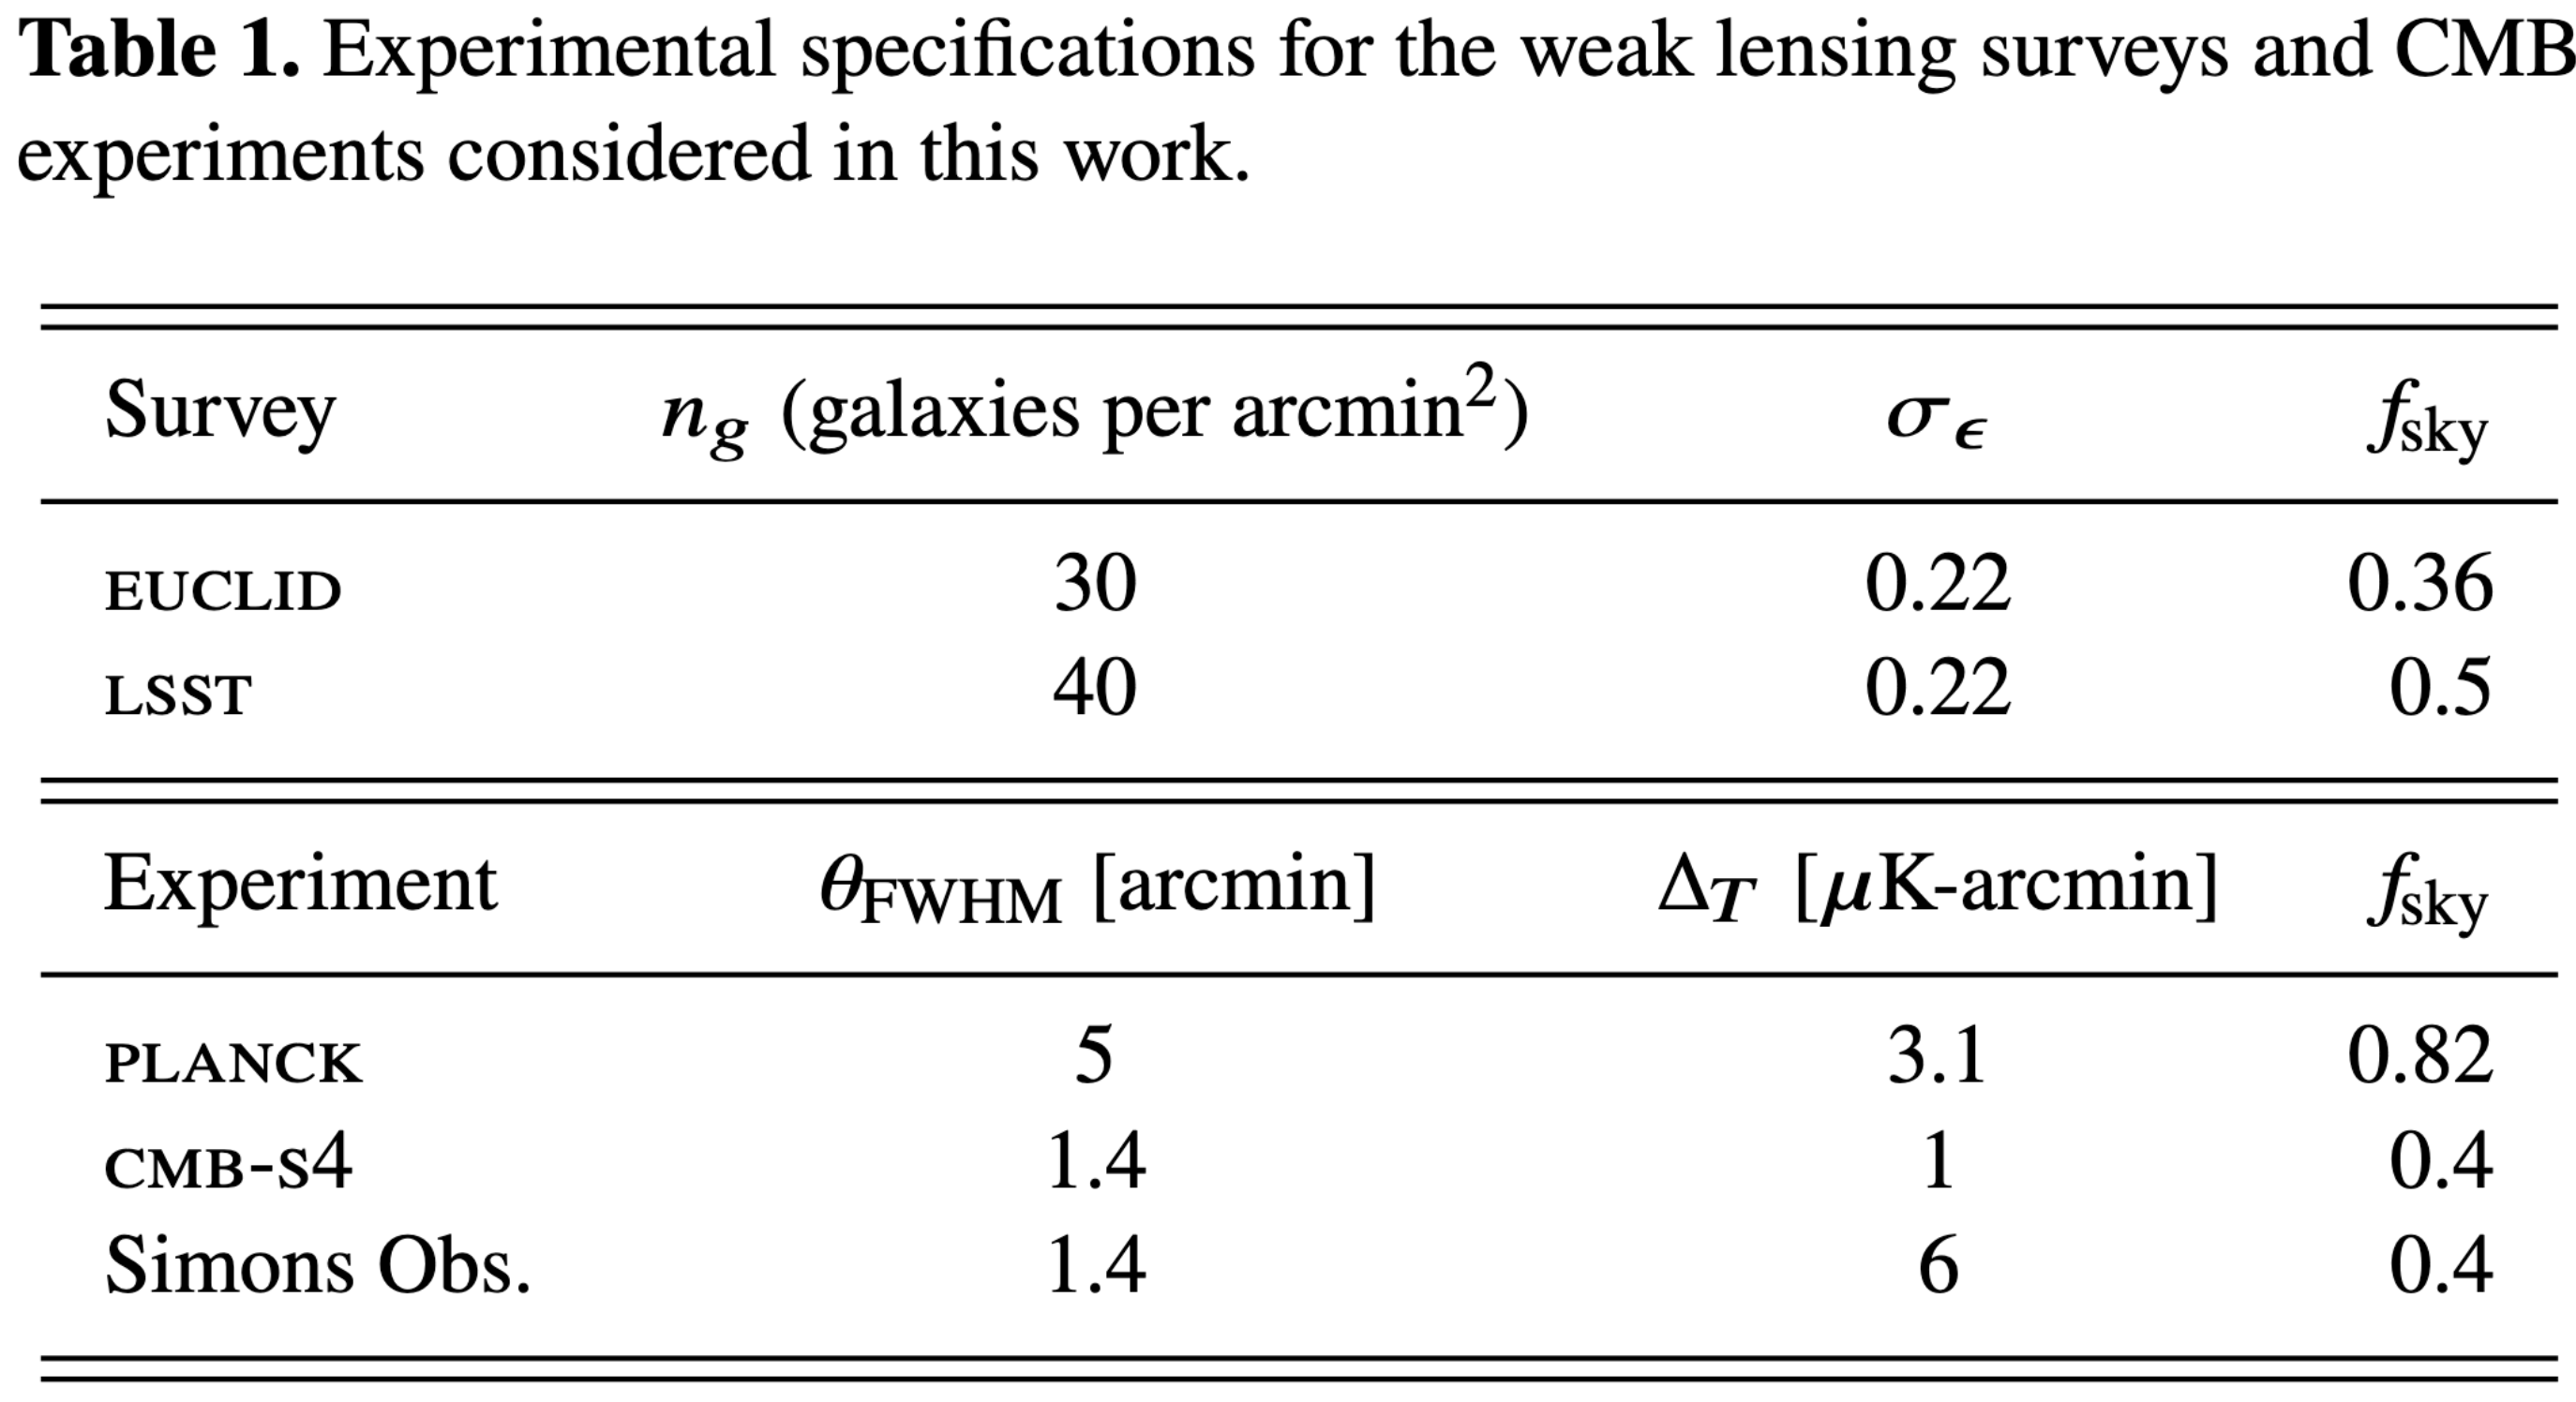